In [1]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from modellens.core.lens import ModelLens

model = GPT2LMHeadModel.from_pretrained("gpt2-medium", attn_implementation="eager")
model.config.output_attentions = True
tokenizer = GPT2Tokenizer.from_pretrained("gpt2-medium")

lens = ModelLens(model)
lens.adapter.set_tokenizer(tokenizer)

print(lens)
print(f"Backend: {lens.adapter.type_of_adapter}")
print(f"Layers: {len(lens.layer_names())}")

/opt/anaconda3/envs/modellens/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 292/292 [00:00<00:00, 12098.67it/s]


ModelLens(backend=huggingface, hooks=0, params=354,823,168)
Backend: huggingface
Layers: 319


## Layer Evolution

In [2]:
from modellens.analysis.layer_evolution import (
    run_layer_evolution,
    run_layer_evolution_comparison,
    compute_layer_kdes,
    compute_evolution_heatmap,
)
from modellens.visualization.layer_evolution import (
    plot_evolution_heatmap,
    plot_evolution_heatmap_comparison,
    plot_kde_overlay,
    plot_kde_grid,
    plot_divergence_by_layer,
    plot_trajectory_comparison,
    plot_token_trajectories,
    format_evolution_summary_html,
)

clean_prompt = "The capital of France is"
corrupted_prompt = "The capital of xyzzy is"

clean_tokens = tokenizer(clean_prompt, return_tensors="pt")
corrupted_tokens = tokenizer(corrupted_prompt, return_tensors="pt")

comparison = run_layer_evolution_comparison(
    lens,
    clean_tokens,
    corrupted_tokens,
    top_k=10,
    tokenizer=tokenizer,
)

print(f"Common layers: {len(comparison['common_layers'])}")
print(f"First 5: {comparison['common_layers'][:5]}")

Common layers: 221
First 5: ['transformer.wte', 'transformer.wpe', 'transformer.drop', 'transformer.h.0.ln_1', 'transformer.h.0.attn.c_proj']


In [3]:
block_layers = [n for n in comparison["common_layers"] if n.startswith("transformer.h.") and n.count(".") == 2]
print(f"Block-level layers: {len(block_layers)}")
print(f"Example: {block_layers[:5]}")

# Build a filtered comparison dict for cleaner plots
filtered = {
    **comparison,
    "common_layers": block_layers,
    "divergences": {n: comparison["divergences"][n] for n in block_layers},
}

Block-level layers: 24
Example: ['transformer.h.0', 'transformer.h.1', 'transformer.h.2', 'transformer.h.3', 'transformer.h.4']


In [4]:
hm_clean = compute_evolution_heatmap(filtered, n_bins=128, sigma=1.5, mode="clean")
fig = plot_evolution_heatmap(hm_clean)
fig.show()

In [5]:
hm_corrupted = compute_evolution_heatmap(filtered, n_bins=128, sigma=1.5, mode="corrupted")
fig = plot_evolution_heatmap(hm_corrupted)
fig.show()

In [6]:
hm_diff = compute_evolution_heatmap(filtered, n_bins=128, sigma=1.5, mode="diff")
fig = plot_evolution_heatmap(hm_diff)
fig.show()

In [7]:
fig = plot_evolution_heatmap_comparison(hm_clean, hm_corrupted, hm_diff)
fig.show()

In [8]:
kdes = compute_layer_kdes(filtered, n_points=256)
mid = block_layers[len(block_layers) // 2]
fig = plot_kde_overlay(kdes, mid)
fig.show()

In [9]:
sample_layers = [
    block_layers[0],
    block_layers[len(block_layers) // 4],
    block_layers[len(block_layers) // 2],
    block_layers[3 * len(block_layers) // 4],
    block_layers[-1],
]
# Remove dupes (if model is small)
sample_layers = list(dict.fromkeys(sample_layers))

fig = plot_kde_grid(kdes, sample_layers, cols=min(len(sample_layers), 3))
fig.show()

In [10]:
fig = plot_divergence_by_layer(filtered, metric="js")
fig.show()

In [11]:
fig = plot_trajectory_comparison(filtered, metric="entropy")
fig.show()

In [12]:
fig = plot_trajectory_comparison(filtered, metric="confidence")
fig.show()

In [13]:
fig = plot_token_trajectories(comparison["clean"], top_n=6)
fig.show()

In [14]:
fig = plot_token_trajectories(comparison["corrupted"], top_n=6)
fig.show()

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sigmas = [0.5, 1.5, 3.0]
fig = make_subplots(rows=1, cols=3, subplot_titles=[f"σ = {s}" for s in sigmas])

for i, s in enumerate(sigmas):
    hm = compute_evolution_heatmap(filtered, n_bins=128, sigma=s, mode="diff")
    fig.add_trace(
        go.Heatmap(
            z=hm["heatmap"], x=hm["bin_centers"],
            y=[n.split(".")[-1] for n in hm["layer_names"]],
            colorscale="RdBu_r", showscale=(i == 2),
        ),
        row=1, col=i + 1,
    )

fig.update_layout(title="Sigma comparison (diff mode)", width=1400, height=500)
fig.show()

In [16]:
from IPython.display import HTML
html = format_evolution_summary_html(filtered)
HTML(html)

Layers analyzed,24
Avg JS divergence,1.1074
Most divergent,transformer.h.4 (3.3434)
Least divergent,transformer.h.21 (0.0000)
Clean first confidence,transformer.h.0.mlp.c_proj
Corrupted first confidence,transformer.h.0.mlp.c_proj


## Layer Evolution 2

In [ ]:
from modellens.analysis.layer_evolution import (
    run_layer_evolution,
    run_layer_evolution_comparison,
    compute_layer_kdes,
    compute_evolution_heatmap,
    summarize_evolution,
    summarize_comparison,
)

clean_prompt = "The capital of France is"
tokens = tokenizer(clean_prompt, return_tensors="pt")
results = run_layer_evolution(
    lens, tokens,
    top_k=5,
    tokenizer=tokenizer,
    capture_full_logits=True,
)

print(summarize_evolution(results))
print(f"\nLayers captured: {len(results['layers'])}")
print(f"Has full logits: {'full_logits' in results['layers'][0]}")
print(f"Logit vector size: {results['layers'][0]['full_logits'].shape}")

Layer evolution: 221 layers analyzed
Position: 4

First confidence: transformer.h.0.mlp.c_proj (entropy: 1.411)
Biggest shift: transformer.h.23 (KL: 27.354)
Top-1 stabilizes after: transformer.ln_f

Top token trajectories (final probability):
   Paris          | start: 0.0000 → final: 0.1741 | peak: 0.3201 ↑
   the            | start: 0.0000 → final: 0.0545 | peak: 1.0000 ↑
   Lyon           | start: 0.0000 → final: 0.0424 | peak: 0.0603 ↑
   not            | start: 0.0000 → final: 0.0306 | peak: 0.9896 ↑
   a              | start: 0.0000 → final: 0.0256 | peak: 0.1134 ↑

Layers captured: 221
Has full logits: True
Logit vector size: (50257,)


In [8]:
clean_prompt = "The capital of France is"
corrupted_prompt = "The capital of xyzzy is"

clean_tokens = tokenizer(clean_prompt, return_tensors="pt")
corrupted_tokens = tokenizer(corrupted_prompt, return_tensors="pt")

comparison = run_layer_evolution_comparison(
    lens,
    clean_tokens,
    corrupted_tokens,
    top_k=5,
    tokenizer=tokenizer,
)

print(summarize_comparison(comparison))
print(f"\nCommon layers: {len(comparison['common_layers'])}")
print(f"Clean layers: {comparison['clean']['num_layers']}")
print(f"Corrupted layers: {comparison['corrupted']['num_layers']}")

Layer evolution comparison: 221 layers

Per-layer divergence (clean vs corrupted):
  Layer                                     KL       JS       L2
  ─────────────────────────────────── ──────── ──────── ────────
  transformer.wte                       0.0000   0.0000   0.0000
  transformer.wpe                       0.0006   0.0006   0.0002
  transformer.drop                      0.0006   0.0006   0.0002
  transformer.h.0.ln_1                  0.0001   0.0001   0.0001
  transformer.h.0.attn.c_proj           0.0040   0.0040   0.0004
  transformer.h.0.attn.resid_dropout    0.0040   0.0040   0.0004
  transformer.h.0.attn                  0.0040   0.0040   0.0004
  transformer.h.0.ln_2                  0.0145   0.0144   0.0050
  transformer.h.0.mlp.c_proj            0.1496   0.1572   0.2230
  transformer.h.0.mlp.dropout           0.1496   0.1572   0.2230
  transformer.h.0.mlp                   0.1496   0.1572   0.2230
  transformer.h.0                       0.2329   0.2497   0.3667
  trans

In [9]:
kdes = compute_layer_kdes(comparison, n_points=256)

print(f"KDE x-axis range: [{kdes['x'][0]:.2f}, {kdes['x'][-1]:.2f}]")
print(f"KDE layers: {len(kdes['clean_kdes'])}")

# Quick sanity check — densities should integrate to ~1
import numpy as np
dx = kdes['x'][1] - kdes['x'][0]
first_layer = comparison['common_layers'][0]
area = np.trapz(kdes['clean_kdes'][first_layer], dx=dx)
print(f"KDE area for {first_layer}: {area:.4f} (should be ~1.0)")

KDE x-axis range: [-357.32, 36.36]
KDE layers: 221
KDE area for transformer.wte: 1.1717 (should be ~1.0)


/var/folders/3g/dp60lf1j62x6b5x7rrx2m1rc0000gn/T/ipykernel_27919/3655074800.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(kdes['clean_kdes'][first_layer], dx=dx)


In [15]:
hm_clean = compute_evolution_heatmap(comparison, n_bins=64, sigma=1.5, mode="clean")
hm_corrupted = compute_evolution_heatmap(comparison, n_bins=64, sigma=1.5, mode="corrupted")
hm_diff = compute_evolution_heatmap(comparison, n_bins=64, sigma=1.5, mode="diff")

print(f"Heatmap shape: {hm_clean['heatmap'].shape}")
print(f"Bin range: [{hm_clean['bin_centers'][0]:.2f}, {hm_clean['bin_centers'][-1]:.2f}]")
print(f"Clean max density: {hm_clean['heatmap'].max():.4f}")
print(f"Diff range: [{hm_diff['heatmap'].min():.4f}, {hm_diff['heatmap'].max():.4f}]")

Heatmap shape: (221, 64)
Bin range: [-321.95, 0.99]
Clean max density: 0.0934
Diff range: [-0.0393, 0.0434]


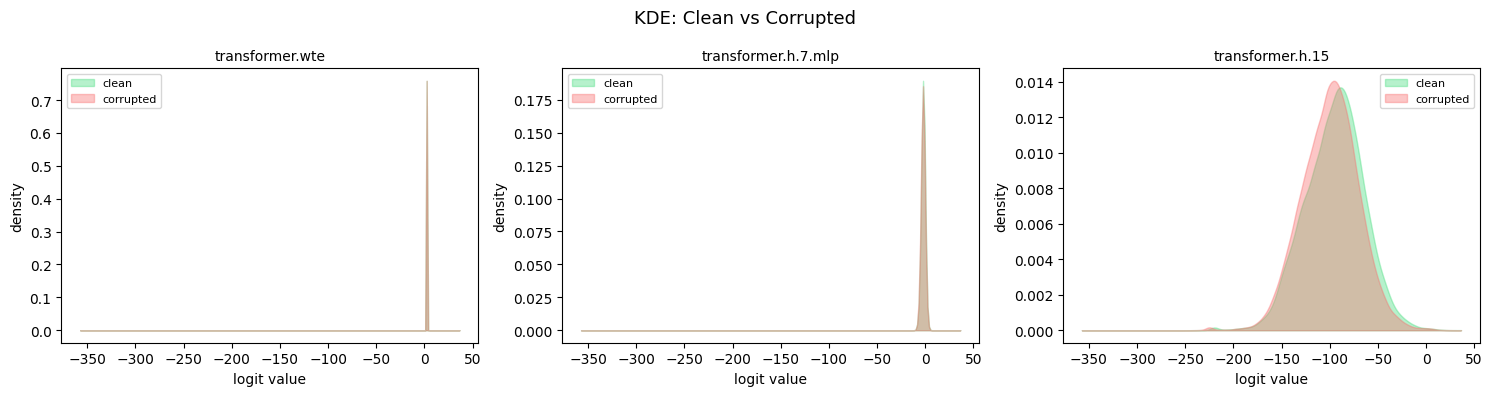

In [16]:
import matplotlib.pyplot as plt

layers_to_plot = comparison['common_layers'][::len(comparison['common_layers']) // 3][:3]
x = kdes['x']

fig, axes = plt.subplots(1, len(layers_to_plot), figsize=(5 * len(layers_to_plot), 4))
for ax, name in zip(axes, layers_to_plot):
    ax.fill_between(x, kdes['clean_kdes'][name], alpha=0.4, label="clean", color="#4ade80")
    ax.fill_between(x, kdes['corrupted_kdes'][name], alpha=0.4, label="corrupted", color="#f87171")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("logit value")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

plt.suptitle("KDE: Clean vs Corrupted", fontsize=13)
plt.tight_layout()
plt.show()

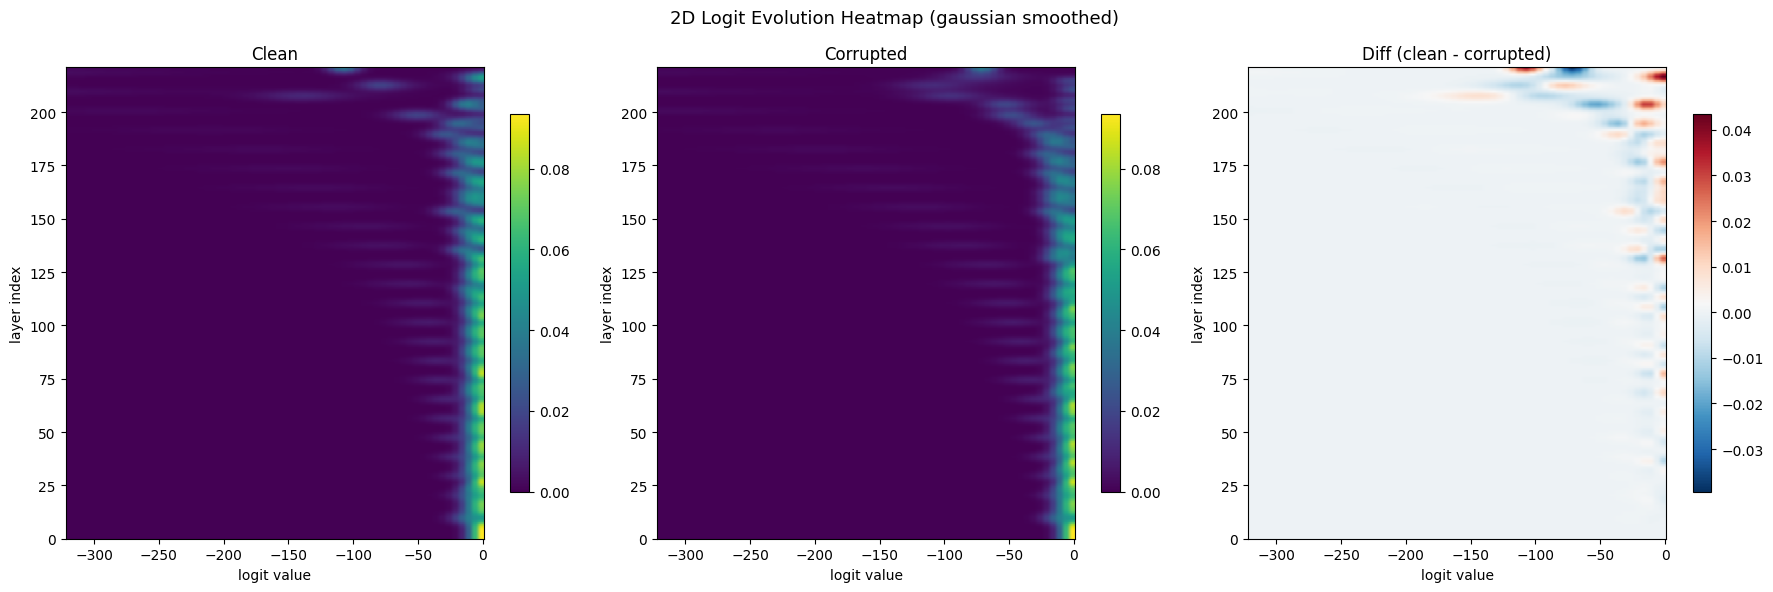

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, hm, title in zip(
    axes,
    [hm_clean, hm_corrupted, hm_diff],
    ["Clean", "Corrupted", "Diff (clean - corrupted)"],
):
    cmap = "RdBu_r" if "Diff" in title else "viridis"
    im = ax.imshow(
        hm['heatmap'],
        aspect='auto',
        origin='lower',
        cmap=cmap,
        extent=[
            hm['bin_centers'][0], hm['bin_centers'][-1],
            0, len(hm['layer_names']),
        ],
    )
    ax.set_title(title)
    ax.set_xlabel("logit value")
    ax.set_ylabel("layer index")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("2D Logit Evolution Heatmap (gaussian smoothed)", fontsize=13)
plt.tight_layout()
plt.show()

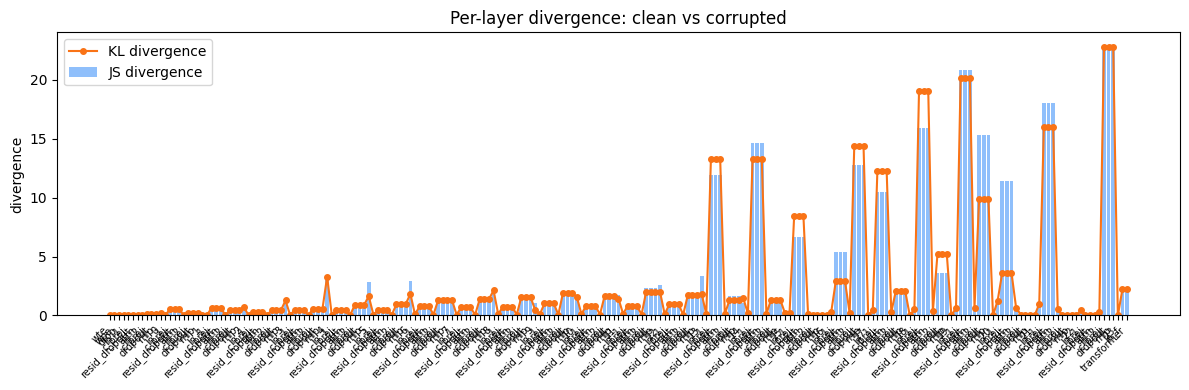

In [19]:
layer_names = comparison['common_layers']
js_values = [comparison['divergences'][n]['js'] for n in layer_names]
kl_values = [comparison['divergences'][n]['kl'] for n in layer_names]

fig, ax = plt.subplots(figsize=(12, 4))
x_pos = range(len(layer_names))
ax.bar(x_pos, js_values, alpha=0.7, label="JS divergence", color="#60a5fa")
ax.plot(x_pos, kl_values, 'o-', color="#f97316", label="KL divergence", markersize=4)
ax.set_xticks(x_pos)
ax.set_xticklabels([n.split('.')[-1] for n in layer_names], rotation=45, ha='right', fontsize=7)
ax.set_ylabel("divergence")
ax.set_title("Per-layer divergence: clean vs corrupted")
ax.legend()
plt.tight_layout()
plt.show()

## Batch Patching

In [2]:
# %% Batch patching test
from modellens.analysis.batch_patching import run_batch_patching, summarize_batch_patching

# Clear hooks
for name, module in model.named_modules():
    module._forward_hooks.clear()

# Create multiple clean/corrupted pairs testing capital-city knowledge
pairs = []
prompts = [
    ("The capital of France is", "The MX of France is"),
    ("The capital of Germany is", "The MX of Germany is"),
    ("The capital of Italy is", "The MX of Italy is"),
    ("The capital of Spain is", "The MX of Spain is"),
    ("The capital of Japan is", "The MX of Japan is"),
]

# Verify they all tokenize to the same length
for clean_str, corrupt_str in prompts:
    c_len = len(tokenizer.tokenize(clean_str))
    k_len = len(tokenizer.tokenize(corrupt_str))
    print(f"{clean_str:35s} ({c_len}) | {corrupt_str:35s} ({k_len})")
    pairs.append((
        tokenizer(clean_str, return_tensors="pt"),
        tokenizer(corrupt_str, return_tensors="pt"),
    ))

The capital of France is            (5) | The MX of France is                 (5)
The capital of Germany is           (5) | The MX of Germany is                (5)
The capital of Italy is             (5) | The MX of Italy is                  (5)
The capital of Spain is             (5) | The MX of Spain is                  (5)
The capital of Japan is             (5) | The MX of Japan is                  (5)


In [8]:
def capital_metric(output):
    """Generic metric: max logit at last position."""
    if hasattr(output, "logits"):
        output = output.logits
    return output[:, -1, :].max(dim=-1).values.mean().item()

batch_results = run_batch_patching(
    lens, pairs, metric_fn=capital_metric,
)

print(summarize_batch_patching(batch_results, top_n=15))

Batch patching: 5/5 pairs successful
Overall consistency: 0.022

Top 15 most important components:

  transformer.h.9.mlp                 | mean effect: +4.781 ± 5.716 | consistency: 0.00 | sign agreement: 100%
  transformer.h.22.attn               | mean effect: +3.481 ± 3.964 | consistency: 0.00 | sign agreement: 100%
  transformer.h.21.mlp                | mean effect: -3.276 ± 3.700 | consistency: 0.00 | sign agreement: 100%
  transformer.h.18.mlp                | mean effect: -3.241 ± 3.876 | consistency: 0.00 | sign agreement: 100%
  transformer.h.17.mlp                | mean effect: -2.236 ± 3.422 | consistency: 0.00 | sign agreement: 60%
  transformer.h.10.mlp                | mean effect: +1.941 ± 2.889 | consistency: 0.00 | sign agreement: 100%
  transformer.h.14.attn               | mean effect: -1.941 ± 2.709 | consistency: 0.00 | sign agreement: 80%
  transformer.h.7.mlp                 | mean effect: -1.688 ± 2.402 | consistency: 0.00 | sign agreement: 60%
  transformer.h

In [3]:
def relative_metric(output):
    """Top-1 probability at last position — comparable across prompts."""
    if hasattr(output, "logits"):
        output = output.logits
    probs = torch.softmax(output[:, -1, :], dim=-1)
    return probs.max(dim=-1).values.mean().item()

# Clear hooks
for name, module in model.named_modules():
    module._forward_hooks.clear()

batch_results = run_batch_patching(
    lens, pairs, metric_fn=relative_metric,
)

print(summarize_batch_patching(batch_results, top_n=15))

Batch patching: 5/5 pairs successful
Overall consistency: 0.206

Top 15 most important components:

  transformer.h.23.mlp                | mean effect: -3.419 ± 2.621 | consistency: 0.23 | sign agreement: 100%
  transformer.h.7.mlp                 | mean effect: +1.613 ± 0.976 | consistency: 0.39 | sign agreement: 100%
  transformer.h.17.mlp                | mean effect: +1.495 ± 0.735 | consistency: 0.51 | sign agreement: 100%
  transformer.h.14.mlp                | mean effect: +1.329 ± 0.649 | consistency: 0.51 | sign agreement: 100%
  transformer.h.10.mlp                | mean effect: -1.326 ± 1.382 | consistency: 0.00 | sign agreement: 100%
  transformer.h.15.mlp                | mean effect: +1.282 ± 0.806 | consistency: 0.37 | sign agreement: 100%
  transformer.h.16.mlp                | mean effect: +1.162 ± 0.557 | consistency: 0.52 | sign agreement: 100%
  transformer.h.22.attn               | mean effect: -1.122 ± 0.849 | consistency: 0.24 | sign agreement: 100%
  transforme

## Circuit Discovery

In [6]:
from modellens.analysis.circuit_discovery import discover_circuit, summarize_circuit

# Clear leftover hooks
for name, module in model.named_modules():
    module._forward_hooks.clear()

clean = tokenizer("The capital of France is", return_tensors="pt")
corrupted = tokenizer("The MX of France is", return_tensors="pt")

paris_id = tokenizer.encode(" Paris")[0]

def france_metric(output):
    if hasattr(output, "logits"):
        output = output.logits
    probs = torch.softmax(output[:, -1, :], dim=-1)
    return probs[:, paris_id].mean().item()

circuit_tight = discover_circuit(
    lens, clean, corrupted,
    metric_fn=france_metric,
    importance_threshold=0.4,
)
print(summarize_circuit(circuit_tight))

Circuit: 10 components, 4 connections
Clean metric: 0.1741
Corrupted metric: 0.0001

CRITICAL components:
  transformer.h.0.mlp (mlp) — effect: +1.000
  transformer.h.7.mlp (mlp) — effect: +0.756

BOOSTER components:
  transformer.h.10.mlp (mlp) — effect: -0.524
  transformer.h.23.mlp (mlp) — effect: -1.329

PROCESSOR components:
  transformer.h.5.mlp (mlp) — effect: +0.458
  transformer.h.7.attn (attention) — effect: +0.431
  transformer.h.14.mlp (mlp) — effect: +0.540
  transformer.h.15.mlp (mlp) — effect: +0.589
  transformer.h.16.mlp (mlp) — effect: +0.431
  transformer.h.17.mlp (mlp) — effect: +0.532



## Logit Lens

In [2]:
from modellens.analysis.logit_lens import run_logit_lens, decode_logit_lens

prompt = "The capital of France is"
tokens = tokenizer(prompt, return_tensors="pt")
top_k = 5

lens.attach_all()
results = run_logit_lens(lens, tokens, top_k=top_k)
decoded = decode_logit_lens(results, tokenizer=tokenizer)

print(f"Prompt: '{prompt}'\n")
for layer_name, predictions in decoded.items():
    tokens_str = ", ".join(f"{tok!r} ({prob:.3f})" for tok, prob in predictions)
    print(f"{layer_name:40s} -> {tokens_str}")

Prompt: 'The capital of France is'

transformer.wte                          -> ' is' (0.000), ' has' (0.000), ' isn' (0.000), ' does' (0.000), ' appears' (0.000)
transformer.wpe                          -> 'anwhile' (0.000), 'SPONSORED' (0.000), 'ippi' (0.000), 'ック' (0.000), 'ña' (0.000)
transformer.drop                         -> ' is' (0.000), ' helicop' (0.000), ' has' (0.000), ' unden' (0.000), ' does' (0.000)
transformer.h.0.ln_1                     -> ' is' (0.000), ' has' (0.000), ' was' (0.000), ' does' (0.000), ' isn' (0.000)
transformer.h.0.attn.c_proj              -> ' offensive' (0.000), ' interior' (0.000), ' Magazine' (0.000), 'initions' (0.000), ' premiere' (0.000)
transformer.h.0.attn.resid_dropout       -> ' offensive' (0.000), ' interior' (0.000), ' Magazine' (0.000), 'initions' (0.000), ' premiere' (0.000)
transformer.h.0.attn                     -> ' offensive' (0.000), ' interior' (0.000), ' Magazine' (0.000), 'initions' (0.000), ' premiere' (0.000)
transformer.h.

## Attention Analysis

In [5]:
from modellens.analysis.attention import run_attention_analysis, head_summary

prompt = "The capital of France is"
attn_results = run_attention_analysis(lens, prompt)

print(f"Number of attention layers: {attn_results['num_layers']}\n")
for name, data in list(attn_results["attention_maps"].items())[:5]:
    print(f"{name}:")
    print(f"  Heads: {data['num_heads']}, Seq length: {data['seq_length']}")
    print(f"  Weights shape: {data['weights'].shape}")

# %% Head Summary — focused vs diffuse heads
summary = head_summary(attn_results)
for name, data in list(summary.items())[:5]:
    print(f"\n{name}:")
    print(f"  Entropy:       {[f'{e:.2f}' for e in data['entropy']]}")
    print(f"  Max attention: {[f'{a:.2f}' for a in data['max_attention']]}")

Number of attention layers: 24

transformer.h.0.attn:
  Heads: 16, Seq length: 5
  Weights shape: torch.Size([1, 16, 5, 5])
transformer.h.1.attn:
  Heads: 16, Seq length: 5
  Weights shape: torch.Size([1, 16, 5, 5])
transformer.h.2.attn:
  Heads: 16, Seq length: 5
  Weights shape: torch.Size([1, 16, 5, 5])
transformer.h.3.attn:
  Heads: 16, Seq length: 5
  Weights shape: torch.Size([1, 16, 5, 5])
transformer.h.4.attn:
  Heads: 16, Seq length: 5
  Weights shape: torch.Size([1, 16, 5, 5])

transformer.h.0.attn:
  Entropy:       ['0.88', '0.90', '0.47', '0.71', '0.84', '0.80', '0.68', '0.72', '0.85', '0.88', '0.75', '0.92', '0.73', '0.80', '0.84', '0.85']
  Max attention: ['0.56', '0.56', '0.79', '0.72', '0.63', '0.66', '0.70', '0.74', '0.61', '0.60', '0.70', '0.54', '0.72', '0.68', '0.63', '0.64']

transformer.h.1.attn:
  Entropy:       ['0.65', '0.48', '0.55', '0.78', '0.60', '0.58', '0.87', '0.56', '0.47', '0.72', '0.24', '0.58', '0.58', '0.58', '0.77', '0.92']
  Max attention: ['0.77'

In [4]:
tokens_list = tokenizer.tokenize(prompt)
print(f"Tokens: {tokens_list}\n")

weights = attn_results["attention_maps"]["transformer.h.4.attn"]["weights"]
head_13 = weights[0, 13]

for i, token in enumerate(tokens_list):
    attn_values = ", ".join(f"{tokens_list[j]} ({head_13[i][j]:.3f})" for j in range(len(tokens_list)))
    print(f"{token:10s} attends to: {attn_values}")

Tokens: ['The', 'Ġcapital', 'Ġof', 'ĠFrance', 'Ġis']

The        attends to: The (1.000), Ġcapital (0.000), Ġof (0.000), ĠFrance (0.000), Ġis (0.000)
Ġcapital   attends to: The (0.998), Ġcapital (0.002), Ġof (0.000), ĠFrance (0.000), Ġis (0.000)
Ġof        attends to: The (0.000), Ġcapital (1.000), Ġof (0.000), ĠFrance (0.000), Ġis (0.000)
ĠFrance    attends to: The (0.000), Ġcapital (0.000), Ġof (0.999), ĠFrance (0.000), Ġis (0.000)
Ġis        attends to: The (0.000), Ġcapital (0.000), Ġof (0.000), ĠFrance (0.999), Ġis (0.000)


## Residual Stream Analysis

In [5]:
from modellens.analysis.residual_stream import run_residual_analysis, identify_critical_layers

block_layers = [f"transformer.h.{i}" for i in range(24)]
lens.attach_layers(block_layers)
residual_results = run_residual_analysis(lens, tokens, layer_names=block_layers)

print("Per-layer residual stream contributions:\n")
for name, data in residual_results["contributions"].items():
    bar = "█" * int(data["relative_contribution"] * 50)
    print(f"{name:20s} | rel: {data['relative_contribution']:.3f} | cos: {data['cosine_similarity']:.3f} | {bar}")

critical = identify_critical_layers(residual_results, threshold=0.05)
print(f"\nCritical layers: {critical}")

Per-layer residual stream contributions:

transformer.h.1      | rel: 0.192 | cos: 0.985 | █████████
transformer.h.2      | rel: 0.387 | cos: 0.985 | ███████████████████
transformer.h.3      | rel: 0.829 | cos: 0.901 | █████████████████████████████████████████
transformer.h.4      | rel: 0.056 | cos: 0.992 | ██
transformer.h.5      | rel: 0.058 | cos: 0.992 | ██
transformer.h.6      | rel: 0.037 | cos: 0.994 | █
transformer.h.7      | rel: 0.034 | cos: 0.991 | █
transformer.h.8      | rel: 0.026 | cos: 0.993 | █
transformer.h.9      | rel: 0.023 | cos: 0.993 | █
transformer.h.10     | rel: 0.025 | cos: 0.992 | █
transformer.h.11     | rel: 0.025 | cos: 0.992 | █
transformer.h.12     | rel: 0.026 | cos: 0.992 | █
transformer.h.13     | rel: 0.028 | cos: 0.993 | █
transformer.h.14     | rel: 0.037 | cos: 0.989 | █
transformer.h.15     | rel: 0.037 | cos: 0.990 | █
transformer.h.16     | rel: 0.045 | cos: 0.989 | ██
transformer.h.17     | rel: 0.042 | cos: 0.992 | ██
transformer.h.18     

## Activation Patching

In [6]:
from modellens.analysis.activation_patching import run_activation_patching

# Clear any leftover hooks
for name, module in model.named_modules():
    module._forward_hooks.clear()

clean = tokenizer("The capital of France is", return_tensors="pt")
corrupted = tokenizer("The MX of France is", return_tensors="pt")

def france_metric(output):
    if hasattr(output, "logits"):
        output = output.logits
    probs = torch.softmax(output[:, -1, :], dim=-1)
    paris_id = tokenizer.encode(" Paris")[0]
    return probs[:, paris_id].mean().item()

patch_results = run_activation_patching(
    lens, clean, corrupted, metric_fn=france_metric
)

print(f"Clean P(Paris):     {patch_results['clean_metric']:.4f}")
print(f"Corrupted P(Paris): {patch_results['corrupted_metric']:.4f}")
print(f"Total effect:       {patch_results['total_effect']:.4f}\n")

for layer, data in patch_results["patch_effects"].items():
    bar = "█" * int(abs(data["normalized_effect"]) * 20)
    sign = "+" if data["normalized_effect"] >= 0 else "-"
    print(f"{layer:35s} | P(Paris): {data['patched_metric']:.4f} | effect: {sign}{abs(data['normalized_effect']):.3f} | {bar}")


Clean P(Paris):     0.1741
Corrupted P(Paris): 0.0001
Total effect:       -0.1739

transformer.h.0.attn                | P(Paris): 0.2112 | effect: -0.214 | ████
transformer.h.0.mlp                 | P(Paris): 0.0001 | effect: +1.000 | ███████████████████
transformer.h.1.attn                | P(Paris): 0.1870 | effect: -0.075 | █
transformer.h.1.mlp                 | P(Paris): 0.2045 | effect: -0.175 | ███
transformer.h.2.attn                | P(Paris): 0.1831 | effect: -0.052 | █
transformer.h.2.mlp                 | P(Paris): 0.1828 | effect: -0.050 | █
transformer.h.3.attn                | P(Paris): 0.1384 | effect: +0.205 | ████
transformer.h.3.mlp                 | P(Paris): 0.1416 | effect: +0.187 | ███
transformer.h.4.attn                | P(Paris): 0.1398 | effect: +0.197 | ███
transformer.h.4.mlp                 | P(Paris): 0.1881 | effect: -0.081 | █
transformer.h.5.attn                | P(Paris): 0.1648 | effect: +0.053 | █
transformer.h.5.mlp                 | P(Paris): 0.0

## Embeddings Analysis

In [7]:
from modellens.analysis.embeddings import run_embeddings_analysis

clean = tokenizer("The capital of France is", return_tensors="pt")
embed_results = run_embeddings_analysis(lens, clean)
tokens_list = tokenizer.tokenize("The capital of France is")

print(f"Tokens: {tokens_list}")
print(f"Embedding dim: {embed_results['embed_dim']}")
print(f"Sequence length: {embed_results['seq_length']}")
print(f"\nPer-token norms:")
for tok, norm in zip(tokens_list, embed_results['norms'][0].tolist()):
    print(f"  {tok:10s} -> {norm:.4f}")

print(f"\nCosine similarity matrix:")
sim = embed_results["similarity_matrix"].numpy().round(3)
print(f"{'':12s} {'  '.join(f'{t:>8s}' for t in tokens_list)}")
for i, tok in enumerate(tokens_list):
    row = "  ".join(f"{sim[i][j]:8.3f}" for j in range(len(tokens_list)))
    print(f"{tok:12s} {row}")

Tokens: ['The', 'Ġcapital', 'Ġof', 'ĠFrance', 'Ġis']
Embedding dim: 1024
Sequence length: 5

Per-token norms:
  The        -> 2.6075
  Ġcapital   -> 3.2428
  Ġof        -> 2.1251
  ĠFrance    -> 3.0892
  Ġis        -> 2.1739

Cosine similarity matrix:
                  The  Ġcapital       Ġof   ĠFrance       Ġis
The             1.000     0.312     0.492     0.421     0.533
Ġcapital        0.312     1.000     0.261     0.263     0.283
Ġof             0.492     0.261     1.000     0.265     0.569
ĠFrance         0.421     0.263     0.265     1.000     0.304
Ġis             0.533     0.283     0.569     0.304     1.000
